In [7]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [8]:
# Przygotowanie i filtrowanie danych
df = pd.read_csv('incidents.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')
cols = ['road_type', 'surface_condition', 'incident_type']
df_2022 = df[df["datetime"].dt.year == 2022].dropna(subset=cols).copy()

In [9]:
# Grupowanie: Top 6 + POZOSTAŁE
top_6 = df_2022['incident_type'].value_counts().nlargest(6).index
df_2022['incident_type'] = df_2022['incident_type'].apply(lambda x: x if x in top_6 else 'POZOSTAŁE')

In [10]:
# Dodanie spacji aby uniknąć błędów przy powtarzających się nazwach między kolumnami
df_2022['n1'] = df_2022['road_type'] + " "
df_2022['n2'] = df_2022['surface_condition'] + "  "
df_2022['n3'] = df_2022['incident_type'] + "   "

In [11]:
# Definicja kolorów
unique_n1 = df_2022['n1'].unique()
unique_n2 = df_2022['n2'].unique()
palette = px.colors.qualitative.Prism + px.colors.qualitative.Safe
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(list(unique_n1) + list(unique_n2))}

In [12]:
# Przygotowanie struktury Sankey
nodes = list(df_2022['n1'].unique()) + list(df_2022['n2'].unique()) + list(df_2022['n3'].unique())
mapping = {name: i for i, name in enumerate(nodes)}

sources, targets, values, link_colors = [], [], [], []

In [13]:
# Road -> Surface
res1 = df_2022.groupby(['n1', 'n2']).size().reset_index(name='count')
for _, row in res1.iterrows():
    sources.append(mapping[row['n1']])
    targets.append(mapping[row['n2']])
    values.append(row['count'])
    c = color_map[row['n1']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))

In [14]:
# Surface -> Incident
res2 = df_2022.groupby(['n2', 'n3']).size().reset_index(name='count')
for _, row in res2.iterrows():
    sources.append(mapping[row['n2']])
    targets.append(mapping[row['n3']])
    values.append(row['count'])
    c = color_map[row['n2']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))

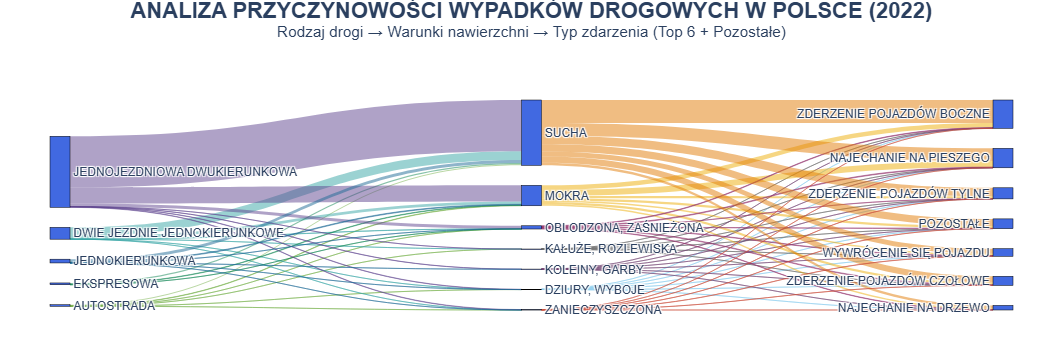

In [16]:
# Renderowanie
fig = go.Figure(go.Sankey(
    arrangement = "snap",
    node = dict(
        pad = 20, thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = [n.strip().upper() for n in nodes],
        color = "royalblue"
    ),
    link = dict(source = sources, target = targets, value = values, color = link_colors)
))

# Layout
fig.update_layout(
    title={
        'text': "<b>ANALIZA PRZYCZYNOWOŚCI WYPADKÓW DROGOWYCH W POLSCE (2022)</b><br><sup>Rodzaj drogi → Warunki nawierzchni → Typ zdarzenia (Top 6 + Pozostałe)</sup>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}
    },
    font=dict(size=12, family="Arial"),
    autosize=True,
    margin=dict(l=50, r=50, t=100, b=50),
    paper_bgcolor="white"
)

fig.write_html("analiza_wypadkow_2022.html", include_plotlyjs='cdn')

fig.show()